In [1]:
import numpy as np
from numpy.random import default_rng
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pymc3 as pm
import torch
import torch.distributions as D

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")

## 1d model


In [2]:
z_dim = 1 
x_dim = 1
n_samples = 1_000

Lambda = torch.randint(low=1, high=10, size=()) + torch.rand(1)
a = torch.rand(1)
sigma = torch.abs(torch.rand(1)) + EPSILON

In [3]:
pz = D.Exponential(Lambda)
z_obs = pz.sample((n_samples,))
mu = a * z_obs
px_z = D.Normal(mu, sigma)
x_obs = px_z.sample()

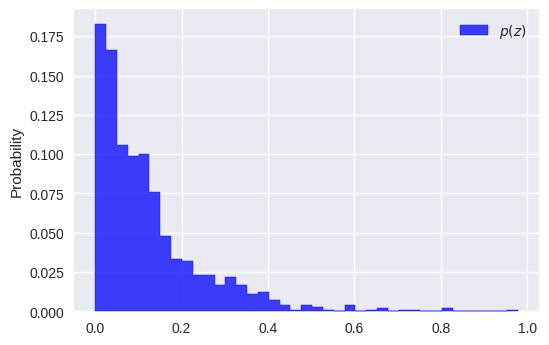

In [4]:
fig, ax = plt.subplots()
fig.set_dpi(100)
sns.histplot(z_obs.numpy().ravel(), color="blue", stat="probability", element="step", label="$p(z)$", ax=ax)
ax.legend()

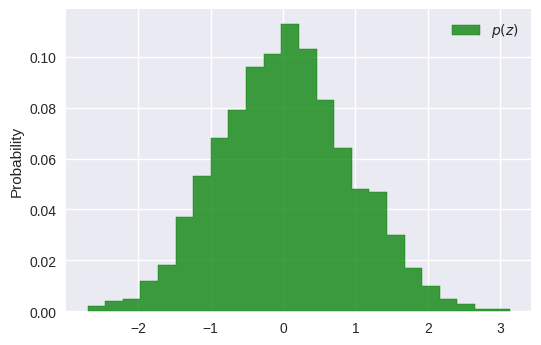

In [5]:
fig, ax = plt.subplots()
fig.set_dpi(100)
sns.histplot(x_obs.numpy().ravel(), color="green", stat="probability", element="step", label="$p(z)$", ax=ax)
ax.legend()

In [11]:
rand_id = torch.randint(low=0, high=n_samples - 1, size=()).item()
z_single_sample = z_obs[rand_id]
x_single_sample = x_obs[rand_id]

In [12]:
z_single_sample, x_single_sample

(tensor([0.2717]), tensor([1.0955]))

In [14]:
model = pm.Model()
with model:
    z = pm.Exponential("neuron", lam=Lambda, shape=z_dim)
    x = pm.Normal("stimulus", mu=a*z, sigma=sigma, observed=x_single_sample)
    trace = pm.sample(1_000, return_inferencedata=False)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
There were 7 divergences after tuning. Increase `target_accept` or reparameterize.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


In [15]:
trace["neuron"].shape

(4000, 1)

In [16]:
z_post = trace["neuron"]

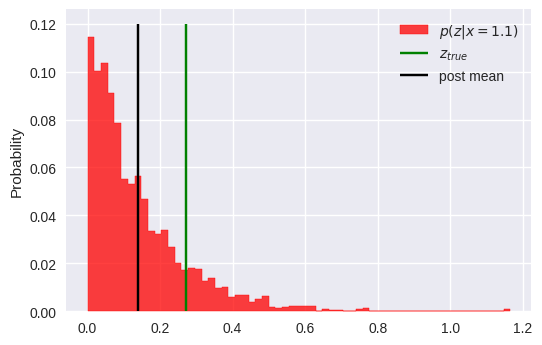

In [27]:
fig, ax = plt.subplots()
fig.set_dpi(100)
sns.histplot(z_post.ravel(), color="red", stat="probability", element="step", label=f"$p(z|x={x_single_sample.item():0.1f})$", ax=ax)
ax.vlines(x=z_single_sample, color="green", ymin=0, ymax=0.12, label="$z_{true}$")
ax.vlines(x=np.mean(z_post.ravel()), color="black", ymin=0, ymax=0.12, label="post mean")
ax.legend()